|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 3:</h2>|<h1>PagedAttention<h1>|
|<h2>Section:</h2>|<h1>Sharing blocks<h1>|
|<h2>Lecture:</h2>|<h1><b>Refcounts and copy-on-write: sharing as a pointer operation<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import hashlib
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# Sharing becomes a pointer operation

A block table is a list of physical block ids. Nothing stops two sequences
from listing the same id.

That one sentence is the whole of stage 09, and it was not available while
the cache was a contiguous buffer per sequence.

In [2]:
class Pool:
  def __init__(self, num_blocks):
    self.free_blocks = list(range(num_blocks))
    self.ref_counts = [0] * num_blocks

  def allocate(self):
    block_id = self.free_blocks.pop()
    self.ref_counts[block_id] = 1
    return block_id

  def share(self, block_id):
    self.ref_counts[block_id] += 1
    return block_id

  def release(self, block_id):
    self.ref_counts[block_id] -= 1
    if self.ref_counts[block_id] == 0:
      self.free_blocks.append(block_id)

  @property
  def used(self):
    return len(self.ref_counts) - len(self.free_blocks)

pool = Pool(1024)
prompt = [pool.allocate() for _ in range(8)]     # a 128-token prompt, blocks of 16
print(f'prompt holds {pool.used} blocks: {prompt}')

prompt holds 8 blocks: [1023, 1022, 1021, 1020, 1019, 1018, 1017, 1016]


In [3]:
# n=4 parallel samples from the same prompt
samples = [[pool.share(block_id) for block_id in prompt] for _ in range(4)]

print(f'after 4 samples share it: {pool.used} blocks still used')
print(f'refcount on the first block: {pool.ref_counts[prompt[0]]}')
print(f'\ncopying instead would have cost {4*len(prompt)} more blocks')

after 4 samples share it: 8 blocks still used
refcount on the first block: 5

copying instead would have cost 32 more blocks


### And then one of them writes

The four samples agree until they do not. One sample makes a different token.
It must write K and V into the block that holds that position, and the four
samples share that block.

A write into that block corrupts the other three. So copy the block first, for
that one sequence. This is **copy-on-write**. `fork` uses the same rule.

In [4]:
def cow_write(pool, table, logical_block):
  block_id = table[logical_block]
  if pool.ref_counts[block_id] == 1:
    return block_id                                  # sole owner, write in place
  private_block = pool.allocate()                       # ... in reality, copy the bytes of block_id here
  pool.release(block_id)
  table[logical_block] = private_block
  return private_block

before = pool.used
cow_write(pool, samples[0], 7)                # sample 0 diverges in its last block
print(f'one divergence cost {pool.used - before} block')
print(f'the other three still share the original: ref = {pool.ref_counts[prompt[7]]}')
print(f'and the first 7 blocks are untouched:     ref = {pool.ref_counts[prompt[0]]}')

one divergence cost 1 block
the other three still share the original: ref = 4
and the first 7 blocks are untouched:     ref = 5


### What that is worth for beam search and n-sampling

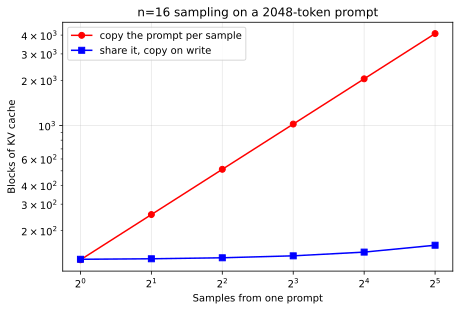

n=  4:   512 blocks copied,  132 shared (4x less)
n= 16:  2048 blocks copied,  144 shared (14x less)


In [5]:
PROMPT_BLOCKS = 128        # a 2048-token prompt
sample_counts = np.array([1,2,4,8,16,32])

copied = sample_counts * PROMPT_BLOCKS
shared = PROMPT_BLOCKS + sample_counts          # the prompt once, plus one diverging block each

plt.figure(figsize=(7,4.5))
plt.plot(sample_counts, copied, 'ro-', label='copy the prompt per sample')
plt.plot(sample_counts, shared, 'bs-', label='share it, copy on write')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Samples from one prompt')
plt.ylabel('Blocks of KV cache')
plt.title('n=16 sampling on a 2048-token prompt')
plt.legend()
plt.grid(alpha=.3)
plt.show()

for num_samples in (4, 16):
  print(f'n={num_samples:>3}: {num_samples*PROMPT_BLOCKS:>5} blocks copied, {PROMPT_BLOCKS+num_samples:>4} shared '
        f'({num_samples*PROMPT_BLOCKS/(PROMPT_BLOCKS+num_samples):.0f}x less)')

### Now do it across requests

So far the sharing was inside one request, where you knew the prefixes
matched because you made them.

Two unrelated users hitting the same chatbot also share a prefix: the system
prompt. Nobody told the engine that. It has to notice.

The trick is to **hash the block's contents** and look it up. Same tokens,
same hash, same physical block. That is a page cache, and the next notebook
measures what it is worth.